
# Syed Kumail Abbas
# Faa23-BBD-135
# Deep Learning Fuel Efficiency Project 

## Objective
This project upgrades the original Machine Learning Fuel Efficiency project into a Deep Learning project using:

- ANN (Artificial Neural Network)
- CNN (1D Convolutional Neural Network)
- Activation Functions
- Optimizers
- Dropout & Regularization
- Model Evaluation
- Web App using Streamlit

The project predicts **MPG (Miles Per Gallon)** of cars.





# #1 Install Required Libraries



In [1]:

!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow streamlit joblib


  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.35.0
    Uninstalling protobuf-7.35.0:
      Successfully uninstalled protobuf-7.35.0


  You can safely remove it manually.



# #2  Import Libraries


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, Flatten
from tensorflow.keras.optimizers import Adam, RMSprop

import joblib



# #3  Load Dataset directlyy from Github



In [3]:

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

df = pd.read_csv(url)

df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino



# #4 Data Cleaning


In [4]:

df.isnull().sum()


mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [5]:

df = df.dropna()

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 30.6+ KB



# #5 Exploratory Data Analysis (EDA)


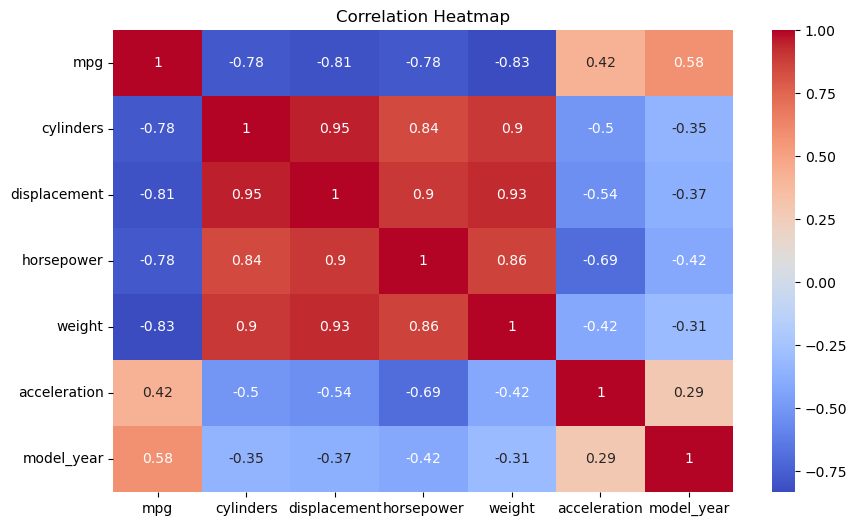

In [6]:

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


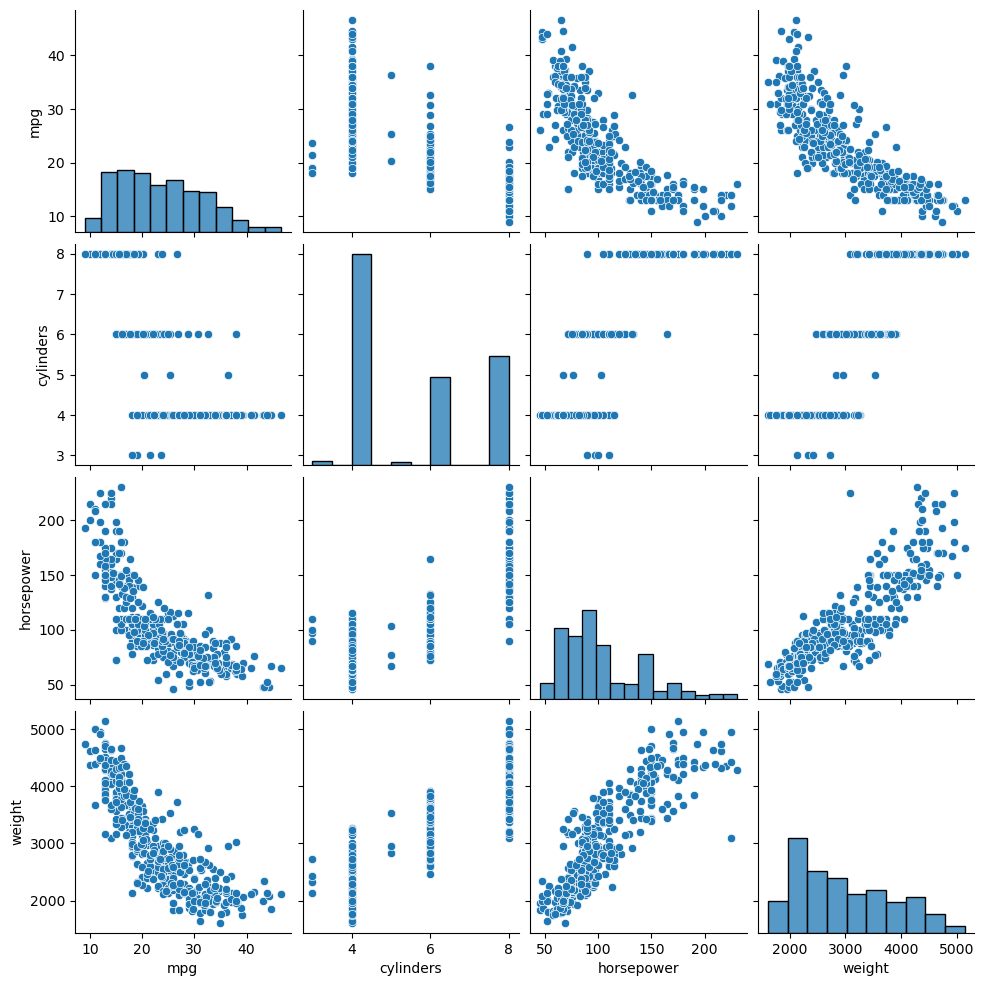

In [7]:

sns.pairplot(df[['mpg','cylinders','horsepower','weight']])
plt.show()



# #6 Feature Selection


In [8]:

X = df[['cylinders','displacement','horsepower','weight']]

y = df['mpg']



# #7 Train Test Split


In [9]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



# #8 Feature Scaling


In [10]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# #9 ANN Model (Artificial Neural Network)

Deep Learning concepts used:

- Dense Layers
- ReLU Activation
- Adam Optimizer
- Dropout
- Epochs
- Batch Size


In [11]:

ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)
])

ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

ann_model.summary()


C:\Users\SK\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,009 (43.00 KB)

 Trainable params: 11,009 (43.00 KB)

 Non-trainable params: 0 (0.00 B)


# #10 Train ANN Model


In [12]:

history = ann_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 580.8707 - mae: 22.7686 - val_loss: 622.5792 - val_mae: 23.7375
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 508.8248 - mae: 21.0788 - val_loss: 510.3663 - val_mae: 21.2611
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 367.8849 - mae: 17.3157 - val_loss: 297.6699 - val_mae: 15.6768
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 176.1388 - mae: 11.3945 - val_loss: 76.4105 - val_mae: 7.3164
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 75.1921 - mae: 7.0742 - val_loss: 55.8001 - val_mae: 5.6795
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 58.5882 - mae: 6.0748 - val_loss: 46.5430 - val_mae: 5.0508
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 52.1165 - mae: 5.7791 - val_loss: 40.4644 - val_mae: 4.7040
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 45.4354 - mae: 5.3155 - val_loss: 34.8521 - val_mae: 4.3790
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━


# #11 ANN Performance


In [13]:

ann_pred = ann_model.predict(X_test_scaled)

ann_r2 = r2_score(y_test, ann_pred)
ann_mae = mean_absolute_error(y_test, ann_pred)

print("ANN R2 Score:", ann_r2)
print("ANN MAE:", ann_mae)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
ANN R2 Score: 0.7116875907100014
ANN MAE: 2.819263511367991



# #12 Plot Training Performance


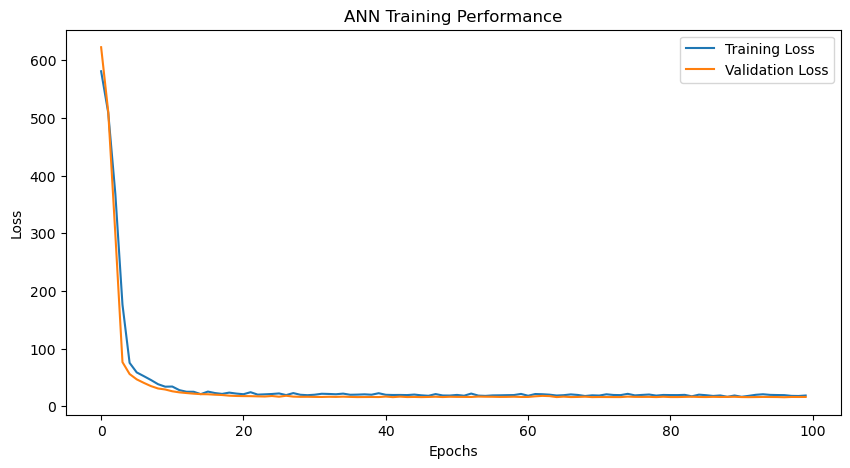

In [14]:

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("ANN Training Performance")
plt.legend()

plt.show()



# #13 CNN Model (1D CNN)

Even though CNN is mostly used for images,
we can still apply 1D CNN on tabular data for learning purposes.


In [15]:

X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

X_train_cnn.shape


(313, 4, 1)

In [16]:

cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu',
           input_shape=(X_train_cnn.shape[1],1)),

    Flatten(),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)
])

cnn_model.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

cnn_model.summary()


C:\Users\SK\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 3, 64)               │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 192)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,657 (57.25 KB)

 Trainable params: 14,657 (57.25 KB)

 Non-trainable params: 0 (0.00 B)


# #14 Train CNN Model


In [17]:

cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 537.7720 - mae: 21.7760 - val_loss: 488.3555 - val_mae: 20.7260
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 314.0722 - mae: 15.7419 - val_loss: 210.2673 - val_mae: 13.1248
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 117.6878 - mae: 9.2453 - val_loss: 50.9611 - val_mae: 5.6643
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 50.8981 - mae: 5.8946 - val_loss: 36.8479 - val_mae: 4.5859
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 41.4025 - mae: 5.1418 - val_loss: 30.8306 - val_mae: 4.1535
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 35.5645 - mae: 4.8204 - val_loss: 25.7754 - val_mae: 3.7562
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 28.5485 - mae: 4.1765 - val_loss: 23.5574 - val_mae: 3.4518
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 24.0622 - mae: 3.8595 - val_loss: 26.0677 - val_mae: 3.6834
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━


# #15 CNN Evaluation


In [18]:

cnn_pred = cnn_model.predict(X_test_cnn)

cnn_r2 = r2_score(y_test, cnn_pred)
cnn_mae = mean_absolute_error(y_test, cnn_pred)

print("CNN R2 Score:", cnn_r2)
print("CNN MAE:", cnn_mae)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
CNN R2 Score: 0.7050437253368267
CNN MAE: 2.8478420450717588



# #16 Compare Models


In [19]:

results = pd.DataFrame({
    'Model': ['ANN', 'CNN'],
    'R2 Score': [ann_r2, cnn_r2],
    'MAE': [ann_mae, cnn_mae]
})

results


,Model,R2 Score,MAE
0,ANN,0.711688,2.819264
1,CNN,0.705044,2.847842


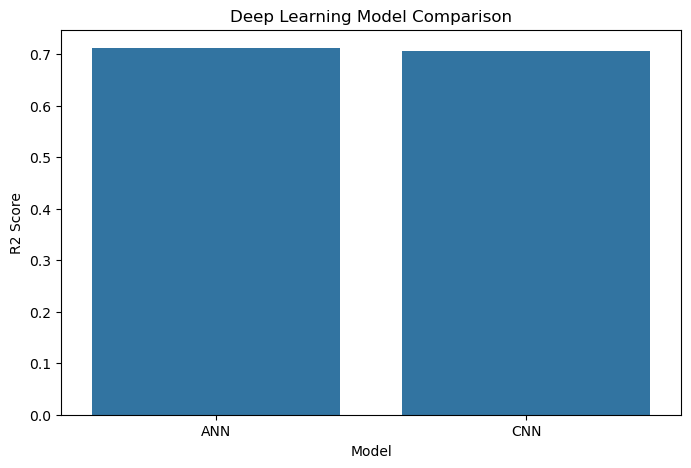

In [20]:

plt.figure(figsize=(8,5))

sns.barplot(data=results, x='Model', y='R2 Score')

plt.title("Deep Learning Model Comparison")

plt.show()



# #17 Save Models


In [21]:

ann_model.save("ann_model.h5")
cnn_model.save("cnn_model.h5")

joblib.dump(scaler, "scaler.pkl")

print("Models Saved Successfully")


Models Saved Successfully



# #18 Prediction on New Car


In [22]:

new_car = pd.DataFrame({
    'cylinders':[4],
    'displacement':[140],
    'horsepower':[90],
    'weight':[2500]
})

new_car_scaled = scaler.transform(new_car)

prediction = ann_model.predict(new_car_scaled)

print("Predicted MPG:", prediction[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted MPG: 25.243832



# #19 Streamlit Web App
Create a new file named:

`app.py`


In [23]:

app_code = '''
import streamlit as st
import pandas as pd
import joblib
from tensorflow.keras.models import load_model

model = load_model("ann_model.h5")
scaler = joblib.load("scaler.pkl")

st.title("Fuel Efficiency Prediction App")

cylinders = st.slider("Cylinders", 2, 12, 4)
displacement = st.number_input("Displacement", value=140.0)
horsepower = st.number_input("Horsepower", value=90.0)
weight = st.number_input("Weight", value=2500.0)

if st.button("Predict MPG"):

    input_df = pd.DataFrame({
        'cylinders':[cylinders],
        'displacement':[displacement],
        'horsepower':[horsepower],
        'weight':[weight]
    })

    input_scaled = scaler.transform(input_df)

    prediction = model.predict(input_scaled)

    st.success(f"Predicted MPG: {prediction[0][0]:.2f}")
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py file created")


app.py file created



# #20 Run Streamlit App
Run the following command in Anaconda Prompt:

streamlit run app.py
